# Analisis EDA dan Cleaning Data MBG TikTok Comments

**Tujuan**: Analisis Eksplorasi Data dan Cleaning untuk dataset komentar TikTok tentang Makan Bergizi Gratis (MBG)

## 1. Setup dan Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Library berhasil diimpor!")

Library berhasil diimpor!


## 2. Load Data

In [2]:
# Load dataset
df = pd.read_csv('data/hasil_processing.csv')

print(f"Shape dataset: {df.shape}")
print(f"\nKolom yang tersedia:")
print(df.columns.tolist())

Shape dataset: (14447, 17)

Kolom yang tersedia:
['Unnamed: 0', 'text', 'diggCount', 'replyCommentTotal', 'createTimeISO', 'uniqueId', 'videoWebUrl', 'uid', 'cid', 'avatarThumbnail', 'source_file', 'text_casefold', 'text_clean', 'tokens', 'token_count', 'tokens_nostop', 'token_count_nostop']


## 3. Basic Data Overview

In [3]:
# Info dataset
print("=" * 60)
print("INFO DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("DESKRIPSI NUMERIK")
print("=" * 60)
df.describe()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14447 entries, 0 to 14446
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          14447 non-null  int64 
 1   text                14407 non-null  object
 2   diggCount           14447 non-null  int64 
 3   replyCommentTotal   14447 non-null  int64 
 4   createTimeISO       14447 non-null  object
 5   uniqueId            14447 non-null  object
 6   videoWebUrl         14447 non-null  object
 7   uid                 14447 non-null  int64 
 8   cid                 14447 non-null  int64 
 9   avatarThumbnail     14447 non-null  object
 10  source_file         14447 non-null  object
 11  text_casefold       14407 non-null  object
 12  text_clean          13574 non-null  object
 13  tokens              14447 non-null  object
 14  token_count         14447 non-null  int64 
 15  tokens_nostop       14447 non-null  object
 16  token_cou

,Unnamed: 0,diggCount,replyCommentTotal,uid,cid,token_count,token_count_nostop
count,14447.000000,14447.000000,14447.000000,1.444700e+04,1.444700e+04,14447.000000,14447.000000
mean,7223.000000,7.372534,0.364436,7.145587e+18,7.584198e+18,13.667405,7.932927
std,4170.634005,253.788193,5.119033,6.059418e+17,2.525125e+16,14.717942,8.506759
min,0.000000,0.000000,0.000000,8.419671e+06,7.476007e+18,0.000000,0.000000
25%,3611.500000,0.000000,0.000000,6.962721e+18,7.573885e+18,4.000000,3.000000
50%,7223.000000,0.000000,0.000000,7.219703e+18,7.594064e+18,10.000000,6.000000
75%,10834.500000,0.000000,0.000000,7.431104e+18,7.598097e+18,18.000000,10.000000
max,14446.000000,24118.000000,256.000000,7.604091e+18,7.605223e+18,278.000000,159.000000


## 4. Missing Values Analysis

Missing Values:
               Missing Count  Percentage (%)
text_clean               873        6.042777
text                      40        0.276874
text_casefold             40        0.276874


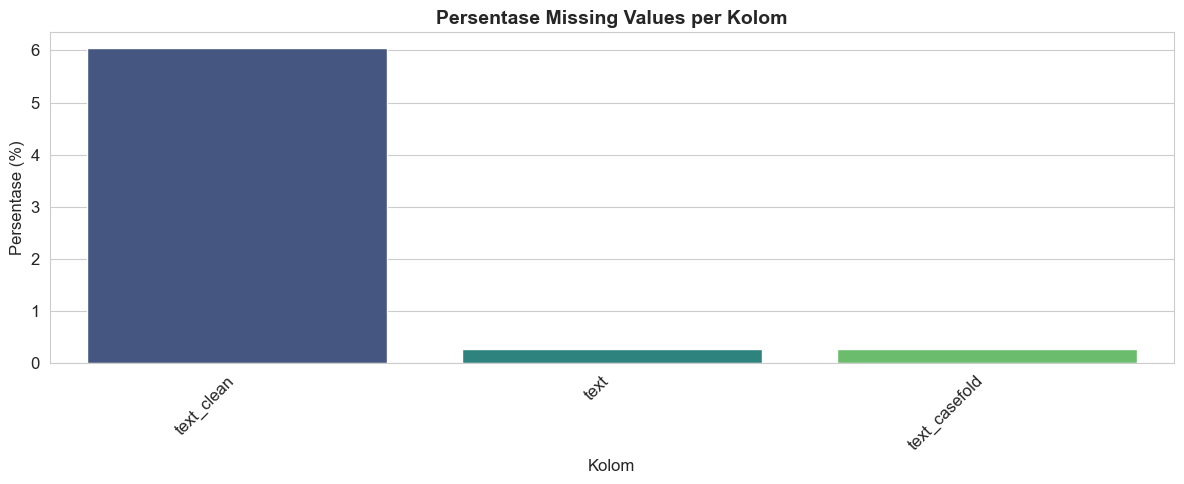

In [4]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values:")
print(missing_df)

# Visualisasi missing values
plt.figure(figsize=(12, 5))
sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='viridis')
plt.title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
plt.xlabel('Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output/missing_values.png', dpi=150)
plt.show()

## 5. Analisis Teks - Empty dan Duplikat

In [5]:
# Cek teks kosong atau NaN
empty_text = df['text'].isna() | (df['text'].str.strip() == '')
print(f"Jumlah teks kosong/NaN: {empty_text.sum()} ({empty_text.sum()/len(df)*100:.2f}%)")

# Cek duplikat berdasarkan teks
duplicate_text = df['text'].duplicated().sum()
print(f"Jumlah teks duplikat: {duplicate_text} ({duplicate_text/len(df)*100:.2f}%)")

# Tampilkan sampel teks kosong
print("\nSampel teks kosong:")
df[empty_text][['text', 'uniqueId', 'createTimeISO']].head(10)

Jumlah teks kosong/NaN: 40 (0.28%)
Jumlah teks duplikat: 658 (4.55%)

Sampel teks kosong:


,text,uniqueId,createTimeISO
1,NaN,sikalengbatak,2025-11-16T15:18:16.000Z
3,NaN,dheanhypuspa,2025-11-17T00:56:13.000Z
139,NaN,selamattahunbaru2021,2025-11-15T11:38:31.000Z
153,NaN,hansv12,2025-11-15T14:00:45.000Z
219,NaN,linaelbarackgmail.com,2025-12-19T05:00:37.000Z
412,NaN,superrboy11,2025-12-29T07:26:22.000Z
455,NaN,sari.cibi,2025-12-29T07:35:09.000Z
535,NaN,jiro.vick,2025-12-29T16:46:52.000Z
4153,NaN,pidepalestina,2025-11-15T10:00:46.000Z
4515,NaN,titin.fatimah505,2025-11-15T05:55:27.000Z


## 6. Analisis Engagement (DiggCount & Replies)

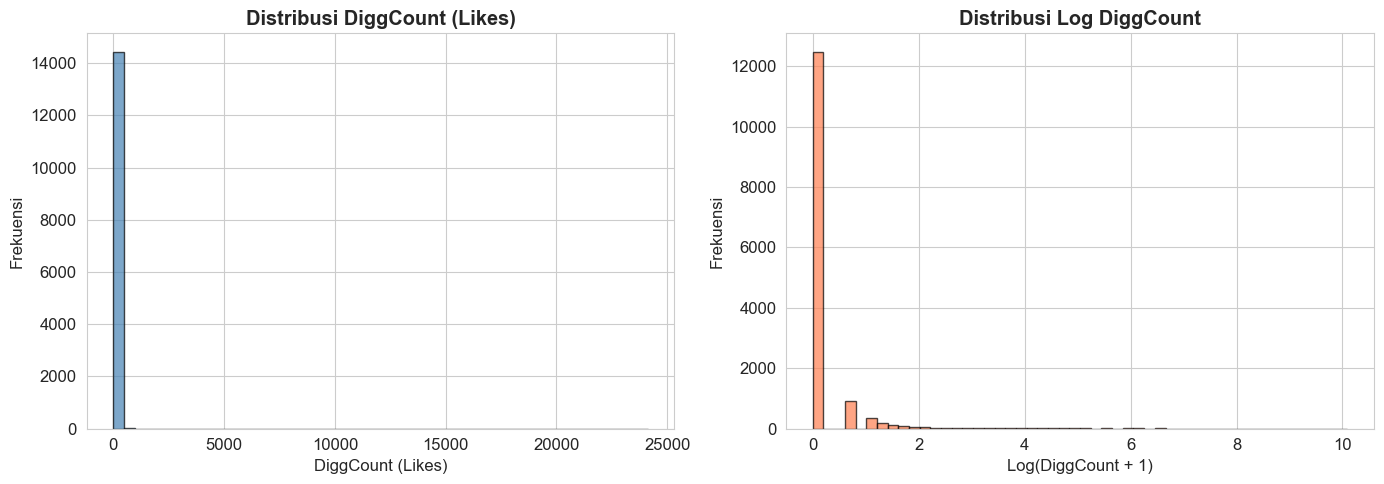


Statistik DiggCount:
  Mean: 7.37
  Median: 0.00
  Max: 24118
  Min: 0


In [6]:
# Distribusi DiggCount (likes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram DiggCount
axes[0].hist(df['diggCount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('DiggCount (Likes)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi DiggCount (Likes)', fontweight='bold')

# Histogram log DiggCount
axes[1].hist(np.log1p(df['diggCount']), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log(DiggCount + 1)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Log DiggCount', fontweight='bold')

plt.tight_layout()
plt.savefig('output/distribution_diggcount.png', dpi=150)
plt.show()

print(f"\nStatistik DiggCount:")
print(f"  Mean: {df['diggCount'].mean():.2f}")
print(f"  Median: {df['diggCount'].median():.2f}")
print(f"  Max: {df['diggCount'].max()}")
print(f"  Min: {df['diggCount'].min()}")

In [7]:
# Top komentar berdasarkan engagement
top_engagement = df.nlargest(10, 'diggCount')[['text', 'diggCount', 'replyCommentTotal', 'uniqueId']]
print("Top 10 Komentar dengan Engagement Tertinggi:")
top_engagement

Top 10 Komentar dengan Engagement Tertinggi:


,text,diggCount,replyCommentTotal,uniqueId
12335,maaf ya ka kalo aku sering ga abisin mbg tapi ...,24118,68,nisogly_au
12333,ITU MAH ENAKK😭😭,12106,14,c0tton_ksyifaa
12334,itulah alasanku selalu menghabiskan yaa..........,9423,30,tatataroarrr
9760,"dan ada orang yang mengatakan ""Prabowo adalah ...",5000,67,meses.coklat
9768,"anakku gk mau mkan mbg,,\ntpi tenang ada mamak...",4436,248,nana_realss
690,"pak, anak saya slalu mmbawa pulang mbgnya enta...",3665,201,nellyakj
11333,Mokel lahh jadi nyaa,3489,53,nabile387
4760,"MBG jangan dihentikan pak, karena kalau dihent...",3098,20,user92958769416198
9758,aku bagi cerita dikit ya guys bulan lalu sebel...,2617,95,makotomia20
11334,kuat banget aura korup ny aampe² ramadhan pun ...,2109,13,king_over_under


## 7. Analisis Token dan Panjang Teks

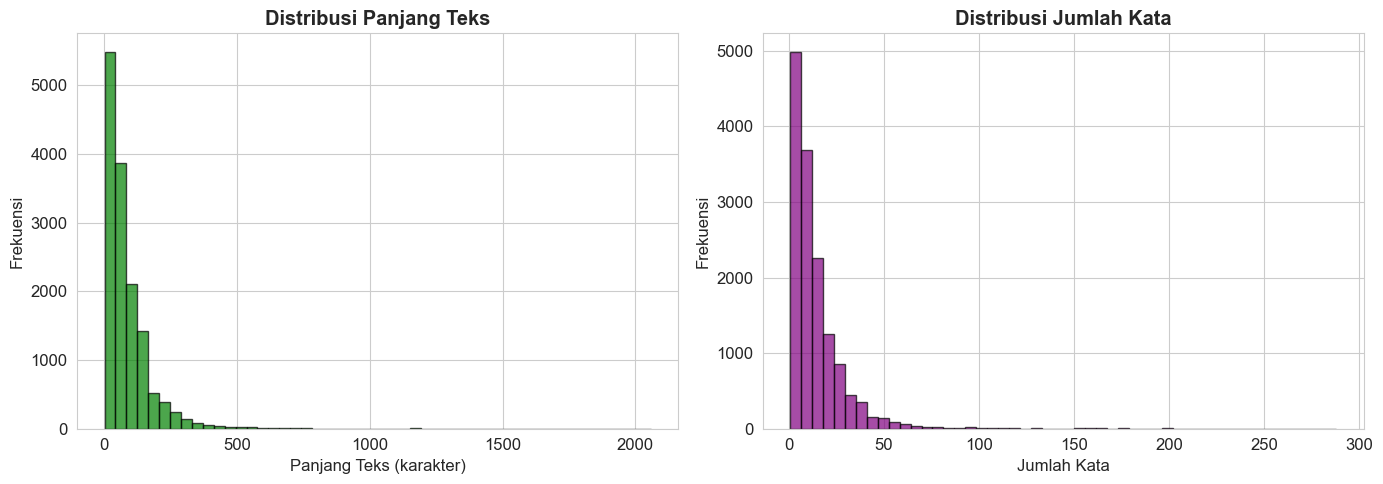


Statistik Panjang Teks:
  Mean: 83.34
  Median: 59.00
  Max: 2057
  Min: 1


In [8]:
# Analisis panjang teks
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi panjang teks (karakter)
axes[0].hist(df['text_length'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Panjang Teks (karakter)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Panjang Teks', fontweight='bold')

# Distribusi jumlah kata
axes[1].hist(df['word_count'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Jumlah Kata', fontweight='bold')

plt.tight_layout()
plt.savefig('output/distribution_text_length.png', dpi=150)
plt.show()

print(f"\nStatistik Panjang Teks:")
print(f"  Mean: {df['text_length'].mean():.2f}")
print(f"  Median: {df['text_length'].median():.2f}")
print(f"  Max: {df['text_length'].max()}")
print(f"  Min: {df['text_length'].min()}")

## 8. Analisis Waktu (Temporal Analysis)

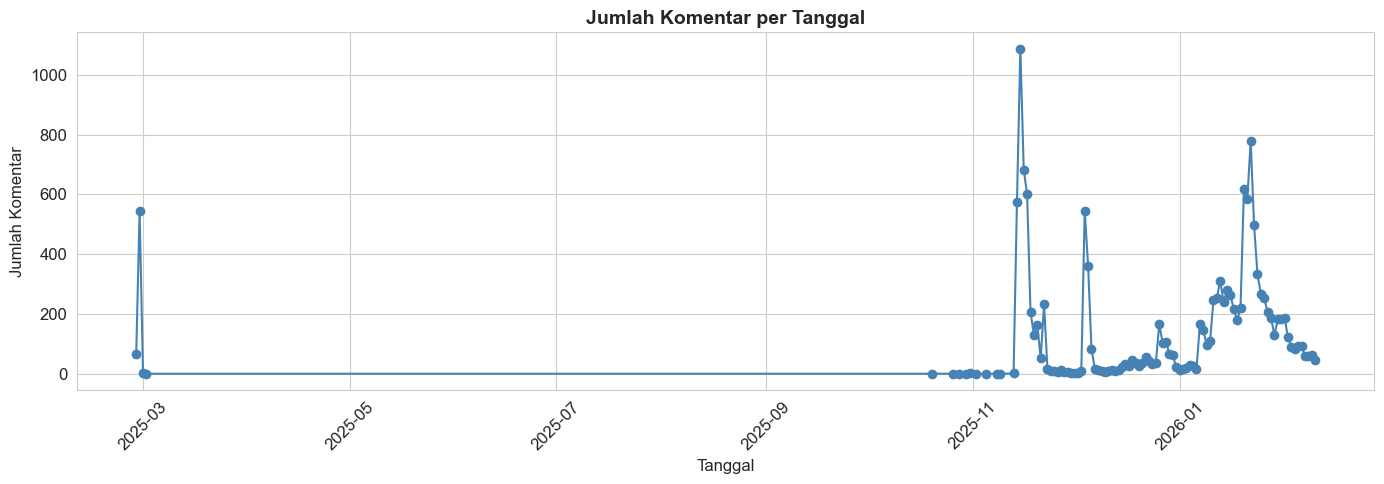


Statistik Waktu:
  Tanggal awal: 2025-02-27
  Tanggal akhir: 2026-02-10
  Rentang hari: 348 hari


In [9]:
# Parse tanggal
df['createTimeISO'] = pd.to_datetime(df['createTimeISO'])
df['date'] = df['createTimeISO'].dt.date
df['month'] = df['createTimeISO'].dt.to_period('M')
df['hour'] = df['createTimeISO'].dt.hour

# Visualisasi komentar per tanggal
comments_per_date = df.groupby('date').size()
plt.figure(figsize=(14, 5))
comments_per_date.plot(kind='line', marker='o', color='steelblue')
plt.title('Jumlah Komentar per Tanggal', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Komentar')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('output/comments_per_date.png', dpi=150)
plt.show()

print(f"\nStatistik Waktu:")
print(f"  Tanggal awal: {df['date'].min()}")
print(f"  Tanggal akhir: {df['date'].max()}")
print(f"  Rentang hari: {(df['date'].max() - df['date'].min()).days} hari")

## 9. Analisis Topik Awal - Kata yang Sering Muncul

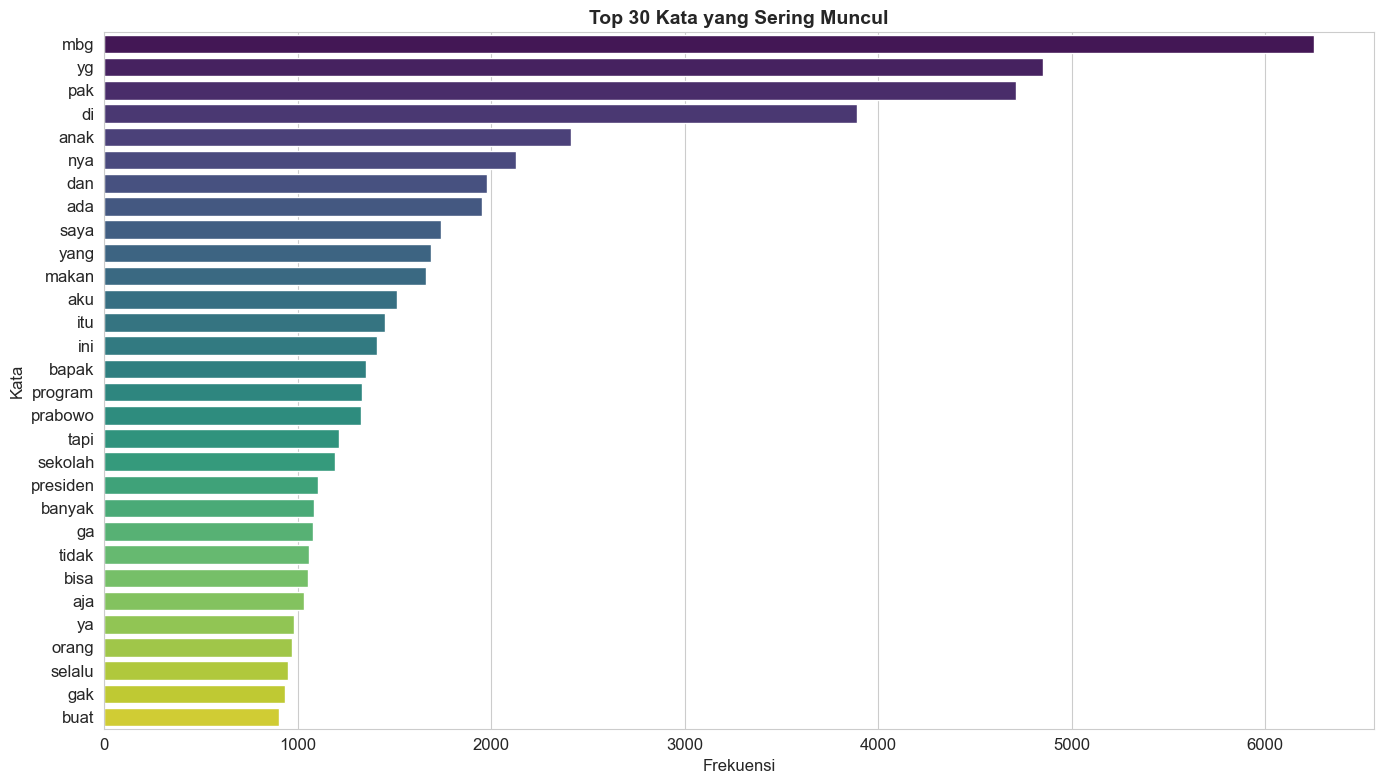


Top 30 Kata:
  1. mbg: 6250
  2. yg: 4852
  3. pak: 4714
  4. di: 3888
  5. anak: 2412
  6. nya: 2127
  7. dan: 1976
  8. ada: 1951
  9. saya: 1742
  10. yang: 1688
  11. makan: 1665
  12. aku: 1512
  13. itu: 1453
  14. ini: 1407
  15. bapak: 1354
  16. program: 1332
  17. prabowo: 1325
  18. tapi: 1215
  19. sekolah: 1194
  20. presiden: 1103
  21. banyak: 1084
  22. ga: 1080
  23. tidak: 1056
  24. bisa: 1051
  25. aja: 1032
  26. ya: 980
  27. orang: 970
  28. selalu: 948
  29. gak: 935
  30. buat: 902


In [10]:
# Parse tokens dari string representation
def parse_tokens(token_str):
    try:
        return ast.literal_eval(token_str)
    except:
        return []

df['tokens_parsed'] = df['tokens'].apply(parse_tokens)

# Flatten semua token
all_words = [word for tokens in df['tokens_parsed'] for word in tokens]
word_freq = Counter(all_words)

# Top 30 kata
top_words = word_freq.most_common(30)
words, counts = zip(*top_words)

plt.figure(figsize=(14, 8))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 30 Kata yang Sering Muncul', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.tight_layout()
plt.savefig('output/top_words.png', dpi=150)
plt.show()

print("\nTop 30 Kata:")
for i, (word, count) in enumerate(top_words, 1):
    print(f"  {i}. {word}: {count}")

## 10. DATA CLEANING

### 10.1 Handle Missing Values

In [11]:
# Buat salinan untuk cleaning
df_clean = df.copy()

# Tampilkan shape awal
print(f"Shape awal: {df_clean.shape}")

# Hapus baris dengan teks kosong atau NaN (komentar tidak valid)
df_clean = df_clean[df_clean['text'].notna()]  # Hapus NaN
df_clean = df_clean[df_clean['text'].str.strip() != '']  # Hapus teks kosong

print(f"Shape setelah hapus NaN & empty: {df_clean.shape}")
print(f"Data yang dihapus: {len(df) - len(df_clean)} ({len(df) - len(df_clean)/len(df)*100:.2f}%)")

Shape awal: (14447, 23)
Shape setelah hapus NaN & empty: (14407, 23)
Data yang dihapus: 40 (14347.28%)


### 10.2 Hapus Duplikat

In [12]:
# Hitung duplikat
duplicates = df_clean['text'].duplicated().sum()
print(f"Jumlah duplikat: {duplicates}")

# Hapus duplikat (pertama disimpan)
df_clean = df_clean.drop_duplicates(subset=['text'], keep='first')

print(f"Shape setelah hapus duplikat: {df_clean.shape}")

Jumlah duplikat: 619
Shape setelah hapus duplikat: (13788, 23)


### 10.3 Normalisasi Teks Tambahan

In [13]:
def advanced_cleaning(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    
    # Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Hapus mention (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Hapus hashtag
    text = re.sub(r'#\w+', '', text)
    
    # Hapus emoji (unicode ranges)
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub('', text)
    
    # Hapus karakter khusus & angka (opsional, keep untuk context)
    # text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Hapus extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning
df_clean['text_clean_advanced'] = df_clean['text'].apply(advanced_cleaning)

# Hapus baris yang setelah cleaning menjadi kosong
df_clean = df_clean[df_clean['text_clean_advanced'].str.strip() != '']

print(f"Shape setelah advanced cleaning: {df_clean.shape}")

# Contoh hasil cleaning
print("\nContoh hasil cleaning:")
sample = df_clean[['text', 'text_clean_advanced']].head(5)
for idx, row in sample.iterrows():
    print(f"\nOriginal: {row['text'][:100]}...")
    print(f"Cleaned: {row['text_clean_advanced'][:100]}...")

Shape setelah advanced cleaning: (13537, 24)

Contoh hasil cleaning:

Original: aav...
Cleaned: aav...

Original: pretttttt...
Cleaned: pretttttt...

Original: halah...
Cleaned: halah...

Original: KOCAK LU AH...
Cleaned: kocak lu ah...

Original: MBG?...
Cleaned: mbg?...


### 10.4 Filter Outlier (Opsional)

In [14]:
# Analisis outlier untuk text_length
Q1 = df_clean['text_length'].quantile(0.25)
Q3 = df_clean['text_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Batas bawah: {lower_bound:.2f}")
print(f"Batas atas: {upper_bound:.2f}")

outliers = df_clean[(df_clean['text_length'] < lower_bound) | (df_clean['text_length'] > upper_bound)]
print(f"Jumlah outlier: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")

# Opsional: pertimbangkan untuk menghapus outlier
# df_clean = df_clean[(df_clean['text_length'] >= lower_bound) & (df_clean['text_length'] <= upper_bound)]
# print(f"Shape setelah hapus outlier: {df_clean.shape}")

Batas bawah: -92.50
Batas atas: 239.50
Jumlah outlier: 747 (5.52%)


## 11. Simpan Data Bersih

In [15]:
# Pilih kolom yang akan disimpan
columns_to_save = [
    'text', 'diggCount', 'replyCommentTotal', 'createTimeISO', 
    'uniqueId', 'videoWebUrl', 'source_file',
    'text_clean', 'tokens', 'token_count',
    'tokens_nostop', 'token_count_nostop',
    'text_clean_advanced', 'text_length', 'word_count',
    'date', 'month', 'hour'
]

df_final = df_clean[columns_to_save].reset_index(drop=True)

# Simpan ke CSV
df_final.to_csv('data/data_cleaned.csv', index=False)

print(f"Data disimpan ke: ../data/data_cleaned.csv")
print(f"Shape final: {df_final.shape}")

Data disimpan ke: ../data/data_cleaned.csv
Shape final: (13537, 18)


## 12. Summary Statistics

In [16]:
print("=" * 60)
print("SUMMARY CLEANING")
print("=" * 60)
print(f"\nData Original:")
print(f"  - Total komentar: {len(df)}")
print(f"  - Teks kosong/NaN dihapus: {len(df) - len(df_clean)}")

print(f"\nData Setelah Cleaning:")
print(f"  - Total komentar: {len(df_final)}")
print(f"  - Kolom: {len(df_final.columns)}")

print(f"\nStatistik Akhir:")
print(f"  - Rata-rata panjang teks: {df_final['text_length'].mean():.2f}")
print(f"  - Rata-rata jumlah kata: {df_final['word_count'].mean():.2f}")
print(f"  - Total engagement (likes): {df_final['diggCount'].sum():,}")
print(f"  - Total komentar dengan replies: {(df_final['replyCommentTotal'] > 0).sum()}")
print(f"  - Unique users: {df_final['uniqueId'].nunique()}")

SUMMARY CLEANING

Data Original:
  - Total komentar: 14447
  - Teks kosong/NaN dihapus: 910

Data Setelah Cleaning:
  - Total komentar: 13537
  - Kolom: 18

Statistik Akhir:
  - Rata-rata panjang teks: 88.45
  - Rata-rata jumlah kata: 14.67
  - Total engagement (likes): 106,381
  - Total komentar dengan replies: 699
  - Unique users: 13144


## 13. Visualisasi Summary

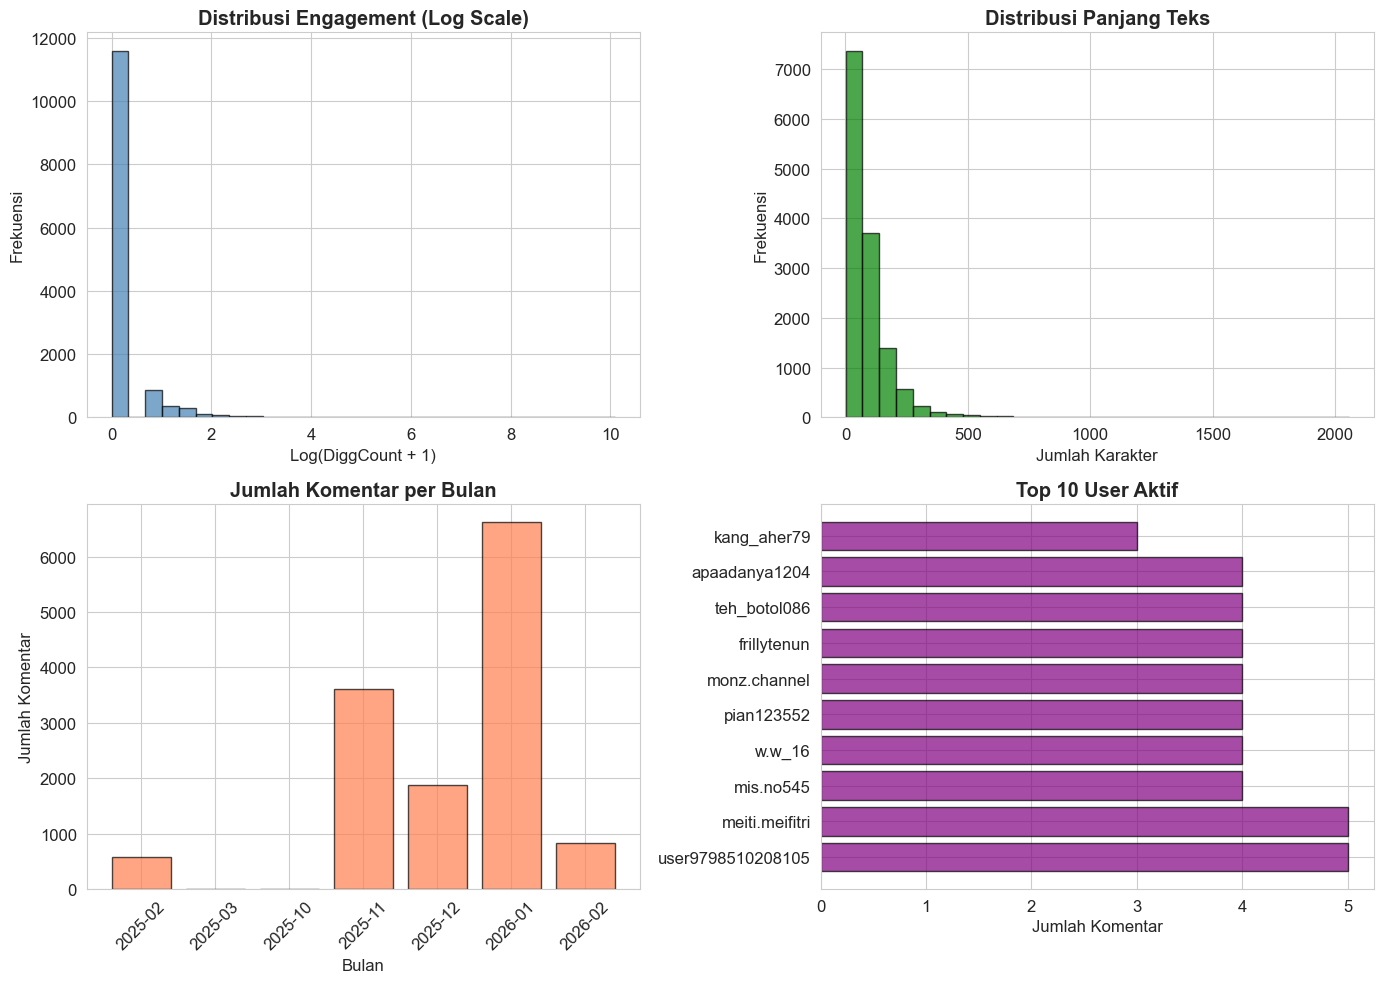

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribusi DiggCount (log scale)
axes[0, 0].hist(np.log1p(df_final['diggCount']), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribusi Engagement (Log Scale)', fontweight='bold')
axes[0, 0].set_xlabel('Log(DiggCount + 1)')
axes[0, 0].set_ylabel('Frekuensi')

# 2. Distribusi Panjang Teks
axes[0, 1].hist(df_final['text_length'], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribusi Panjang Teks', fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Karakter')
axes[0, 1].set_ylabel('Frekuensi')

# 3. Jumlah Komentar per Bulan
comments_per_month = df_final.groupby('month').size()
axes[1, 0].bar(range(len(comments_per_month)), comments_per_month.values, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Jumlah Komentar per Bulan', fontweight='bold')
axes[1, 0].set_xlabel('Bulan')
axes[1, 0].set_ylabel('Jumlah Komentar')
axes[1, 0].set_xticks(range(len(comments_per_month)))
axes[1, 0].set_xticklabels([str(m) for m in comments_per_month.index], rotation=45)

# 4. Top 10 User dengan Komentar Terbanyak
user_comments = df_final['uniqueId'].value_counts().head(10)
axes[1, 1].barh(range(len(user_comments)), user_comments.values, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Top 10 User Aktif', fontweight='bold')
axes[1, 1].set_xlabel('Jumlah Komentar')
axes[1, 1].set_yticks(range(len(user_comments)))
axes[1, 1].set_yticklabels(user_comments.index)

plt.tight_layout()
plt.savefig('output/eda_summary.png', dpi=150)
plt.show()

---

## Langkah Berikutnya

Setelah EDA dan Cleaning selesai, langkah selanjutnya adalah:
1. **Topic Modeling** - Menggunakan LDA, NMF, atau model lainnya
2. **Visualisasi Hasil Modeling** - WordCloud, topic distribution, dll
3. **Sentiment Analysis** (opsional)
4. **Interpretasi Hasil**

Data sudah siap untuk diproses lebih lanjut.